# Assignment 01 - Diabetes Prediction Intelligent System

**Course:** Intelligent System Development

**Assignment:** Assignment 01 - From Data Representation to a First Intelligent System

**Problem Type:** Supervised Binary Classification

## 1. System and Problem Definition

The objective of this project is to develop a small intelligent system
that predicts whether an observation belongs to the diabetes-positive
or diabetes-negative class based on structured health-related data.

This is a supervised binary classification problem.

The system receives numerical health-related information as input,
represents the information as a feature vector, processes the feature
vector using a traditional machine learning model, and produces a
binary prediction.

### Input
Structured health-related features describing one observation.

### Target
`Outcome`

- `0`: Negative class
- `1`: Positive class

### Output
A predicted diabetes class for a previously unseen observation.

### Initial System Pipeline

Real-world health information
→ Structured data
→ Feature representation
→ Preprocessing
→ Traditional Machine Learning Model
→ Prediction
→ Application Output

## 2. Dataset Source

The project uses the local dataset:

`data/diabetes_dataset.csv`

The dataset is used as structured input data for a supervised
classification problem.

The exact number of observations, features, data types, and target
distribution will be determined from the dataset itself in the
following analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "diabetes_dataset.csv"

print(DATA_PATH)
print(DATA_PATH.exists())

/home/hiubeo/Documents/TKHTTM/Assignment01_Diabetes/data/diabetes_dataset.csv
True


In [3]:
df = pd.read_csv(DATA_PATH)

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Initial Dataset Inspection

In [4]:
df.shape

(768, 9)

In [5]:
df.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
if "Outcome" not in df.columns:
    raise KeyError("Expected target column 'Outcome' was not found.")

df["Outcome"].value_counts().sort_index()

Outcome
0    500
1    268
Name: count, dtype: int64

## 4. Dataset Summary

Based on the initial inspection of `data/diabetes_dataset.csv`:

- Number of observations: 768
- Number of columns: 9
- Target column: `Outcome`
- Number of candidate input features: 8
- Numerical candidate input features: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`
- Categorical candidate input features: none detected in the raw dataset
- Target data type: `int64`
- Direct missing values: 0
- Duplicate rows: 0
- Problem type: Supervised Binary Classification

The target column `Outcome` contains two classes: `0` and `1`.

Zero values may appear in some health measurement columns such as
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.
At this step, these values are only noted and are not replaced,
removed, scaled, or otherwise processed.

## 5. Feature Table

| Column | Role | Data Type | Meaning |
| ------ | ---- | --------- | ------- |
| `Pregnancies` | Candidate Input Feature | `int64` | Number of pregnancies |
| `Glucose` | Candidate Input Feature | `int64` | Plasma glucose concentration |
| `BloodPressure` | Candidate Input Feature | `int64` | Diastolic blood pressure |
| `SkinThickness` | Candidate Input Feature | `int64` | Triceps skin fold thickness |
| `Insulin` | Candidate Input Feature | `int64` | Serum insulin measurement |
| `BMI` | Candidate Input Feature | `float64` | Body mass index |
| `DiabetesPedigreeFunction` | Candidate Input Feature | `float64` | Diabetes pedigree function score |
| `Age` | Candidate Input Feature | `int64` | Age in years |
| `Outcome` | Target | `int64` | Binary class label: `0` negative class, `1` positive class |

All non-target columns are treated as candidate input features at this
stage. The final selection of 6 features will be performed in a later
step.

## 6. Data Representation

Each observation is initially represented as a numerical feature vector
with 8 candidate features:

```text
x = [
    Pregnancies,
    Glucose,
    BloodPressure,
    SkinThickness,
    Insulin,
    BMI,
    DiabetesPedigreeFunction,
    Age
]
```

The target variable is:

```text
y = Outcome
```

where:

```text
Outcome = 0 -> Negative class
Outcome = 1 -> Positive class
```

The model does not directly receive a person or the real world as input.
Instead, it receives a numerical feature vector. This representation
determines which information is made available to the model.

At this stage, the representation is only the initial representation
using 8 candidate features. The final representation will contain 6
features after Feature Selection in a later step. No 6-feature selection
is performed in this step.

### Formal Problem Statement

Given a numerical feature vector describing a previously unseen
observation, predict whether its Outcome belongs to the negative class
(0) or positive class (1).

```text
Input: x ∈ R^8
Target: y ∈ {0, 1}
Task: Binary Classification
```

Here, `R^8` describes the initial representation with 8 candidate
features. After Feature Selection, the final representation will change
to `R^6`.

## 7. Feature and Target Analysis

In [11]:
candidate_features = [column for column in df.columns if column != "Outcome"]

feature_analysis = pd.DataFrame({
    "Feature": df.columns,
    "Role": ["Target" if column == "Outcome" else "Candidate Feature" for column in df.columns],
    "Data Type": [str(df[column].dtype) for column in df.columns],
    "Min": [df[column].min() for column in df.columns],
    "Max": [df[column].max() for column in df.columns],
    "Mean": [df[column].mean() for column in df.columns],
    "Median": [df[column].median() for column in df.columns],
    "Zero Count": [(df[column] == 0).sum() for column in df.columns],
    "Unique Values": [df[column].nunique() for column in df.columns],
})

feature_analysis

,Feature,Role,Data Type,Min,Max,Mean,Median,Zero Count,Unique Values
0,Pregnancies,Candidate Feature,int64,0.000,17.00,3.845052,3.0000,111,17
1,Glucose,Candidate Feature,int64,0.000,199.00,120.894531,117.0000,5,136
2,BloodPressure,Candidate Feature,int64,0.000,122.00,69.105469,72.0000,35,47
3,SkinThickness,Candidate Feature,int64,0.000,99.00,20.536458,23.0000,227,51
4,Insulin,Candidate Feature,int64,0.000,846.00,79.799479,30.5000,374,186
5,BMI,Candidate Feature,float64,0.000,67.10,31.992578,32.0000,11,248
6,DiabetesPedigreeFunction,Candidate Feature,float64,0.078,2.42,0.471876,0.3725,0,517
7,Age,Candidate Feature,int64,21.000,81.00,33.240885,29.0000,0,52
8,Outcome,Target,int64,0.000,1.00,0.348958,0.0000,500,2


### Target Distribution

In [12]:
df["Outcome"].value_counts().sort_index()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
df["Outcome"].value_counts(normalize=True).sort_index() * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

The target distribution is not perfectly balanced. Class `0` has 500
observations, while class `1` has 268 observations. In percentage terms,
class `0` represents approximately 65.10% of the dataset and class `1`
represents approximately 34.90%.

Class `0` is the majority class. The difference between the two classes
is noticeable, but no resampling, SMOTE, or target distribution
modification is performed in this step.

### Zero-Value Counts

In [14]:
zero_counts = (df.drop(columns=["Outcome"]) == 0).sum()
zero_counts

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [15]:
zero_summary = pd.DataFrame({
    "Feature": zero_counts.index,
    "Zero Count": zero_counts.values,
    "Zero Percentage": (zero_counts.values / len(df)) * 100,
})

zero_summary

,Feature,Zero Count,Zero Percentage
0,Pregnancies,111,14.453125
1,Glucose,5,0.651042
2,BloodPressure,35,4.557292
3,SkinThickness,227,29.557292
4,Insulin,374,48.697917
5,BMI,11,1.432292
6,DiabetesPedigreeFunction,0,0.000000
7,Age,0,0.000000


### Zero-Value Inspection

#### Zero values that may be valid

`Pregnancies = 0` can be valid and should not automatically be treated
as a missing value.

#### Zero values that require later review

The initial inspection shows zero values in the following health
measurement columns:

- `Glucose`: 5 zero values
- `BloodPressure`: 35 zero values
- `SkinThickness`: 227 zero values
- `Insulin`: 374 zero values
- `BMI`: 11 zero values

These are recorded as potential missing or invalid zero values for later
Data Cleaning. They are not replaced, imputed, removed, or scaled in this
step.

`Age` has 0 zero values, and `DiabetesPedigreeFunction` has 0 zero
values based on the current dataset.

### Range and Basic Value Inspection

Based on `df.describe()` and the feature analysis table, the following
points should be noted for later Data Cleaning:

- `Pregnancies` ranges from 0 to 17. A value of 0 can be valid.
- `Glucose` ranges from 0 to 199, with 5 zero values that require later review.
- `BloodPressure` ranges from 0 to 122, with 35 zero values that require later review.
- `SkinThickness` ranges from 0 to 99, with 227 zero values that require later review.
- `Insulin` ranges from 0 to 846, with 374 zero values that require later review.
- `BMI` ranges from 0 to 67.1, with 11 zero values that require later review.
- `DiabetesPedigreeFunction` ranges from 0.078 to 2.42 and has no zero values.
- `Age` ranges from 21 to 81 and has no zero values.

No outliers are removed, no IQR rule is applied, no winsorization is
performed, and no standardization is applied in this step.

### Raw Feature vs Model Input

```text
Raw CSV values
        ↓
Initial numerical features
        ↓
[Data Cleaning - not performed yet]
        ↓
[Feature Selection - not performed yet]
        ↓
[Preprocessing - not performed yet]
        ↓
Final model input
```

The raw features are not necessarily the final model input. Some zero
values will be reviewed in a later Data Cleaning step. The current 8
candidate features will later be reduced to 6 features during Feature
Selection.

Preprocessing will be fit only on the training data in a later step to
avoid data leakage. None of those steps are performed here.

## 8. Data Quality Summary

Based on the current inspection:

1. The dataset has 768 observations.
2. The dataset has 8 candidate input features.
3. The target variable is `Outcome`.
4. There are 0 direct NaN missing values.
5. There are 0 duplicate rows.
6. Target distribution: class `0` has 500 observations (65.10%), and class `1` has 268 observations (34.90%).
7. Candidate features with zero values: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.
8. Features with notable zero counts: `Insulin` (374), `SkinThickness` (227), `BloodPressure` (35), `BMI` (11), and `Glucose` (5).
9. Later Data Cleaning should review potential missing or invalid zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.

At this step, the dataset is only inspected. No values are modified, no
rows are removed, no scaling is applied, no charts are created, and all 8
candidate features are still kept.

## 9. Exploratory Data Analysis

The purpose of this exploratory data analysis is to inspect the
distribution of important variables before data cleaning and machine
learning.

The raw dataset is used in this section so that unusual values,
including potential invalid zero values, remain visible.

Five distribution charts are examined:

1. Outcome
2. Glucose
3. BMI
4. Age
5. BloodPressure

### Chart 1: Outcome Distribution

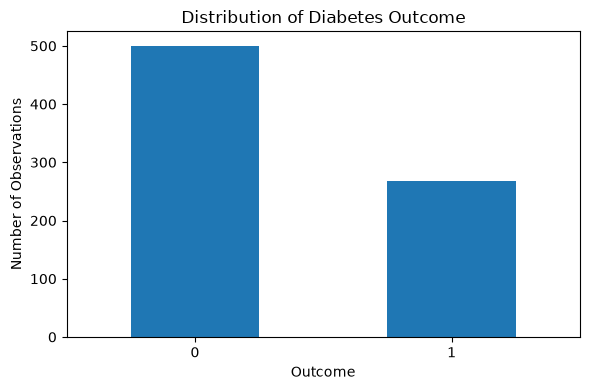

In [16]:
outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
outcome_counts.plot(kind="bar")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

Class `0` has 500 observations, and class `1` has 268 observations.
This corresponds to approximately 65.10% for class `0` and 34.90% for
class `1`.

The dataset is not perfectly balanced. Class `0` appears more frequently
than class `1`. No resampling or class balancing is performed in this
EDA step.

### Chart 2: Glucose Distribution

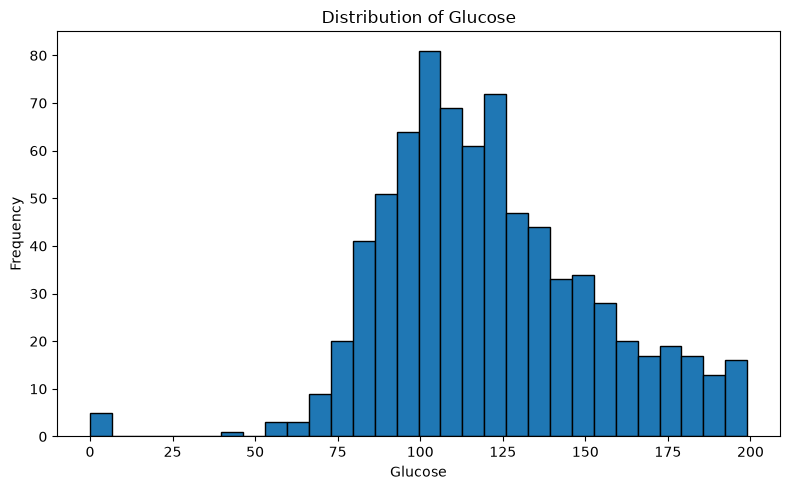

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["Glucose"], bins=30, edgecolor="black")
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The current `Glucose` range is from 0 to 199. There are 5 observations
where `Glucose = 0`; these values have been recorded as potential
invalid values.

Most observations are concentrated around the middle of the observed
range, with the interquartile range from 99.0 to 140.25 and a median of
117.0. The zero values remain visible in this raw-data visualization and
are not processed in this EDA step.

### Chart 3: BMI Distribution

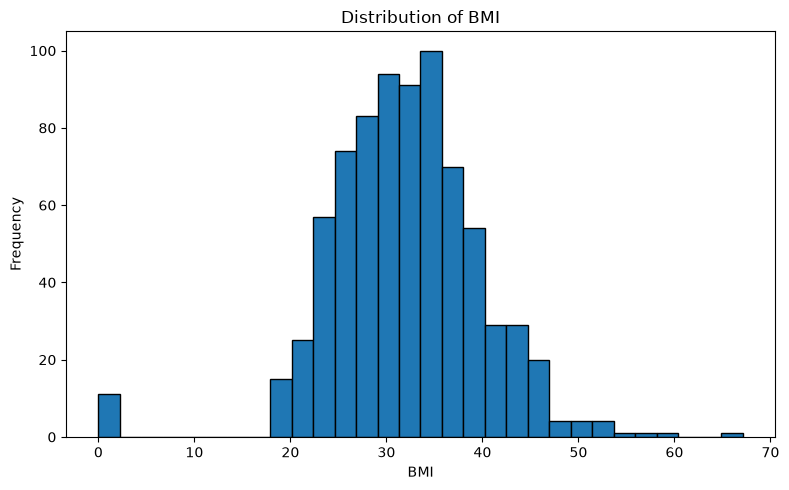

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["BMI"], bins=30, edgecolor="black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The current `BMI` range is from 0 to 67.1. There are 11 observations
where `BMI = 0`; these values are considered potential invalid values to
review during Data Cleaning.

Most observations are concentrated around the middle BMI range, with the
interquartile range from 27.3 to 36.6 and a median of 32.0. No values are
changed in this step.

### Chart 4: Age Distribution

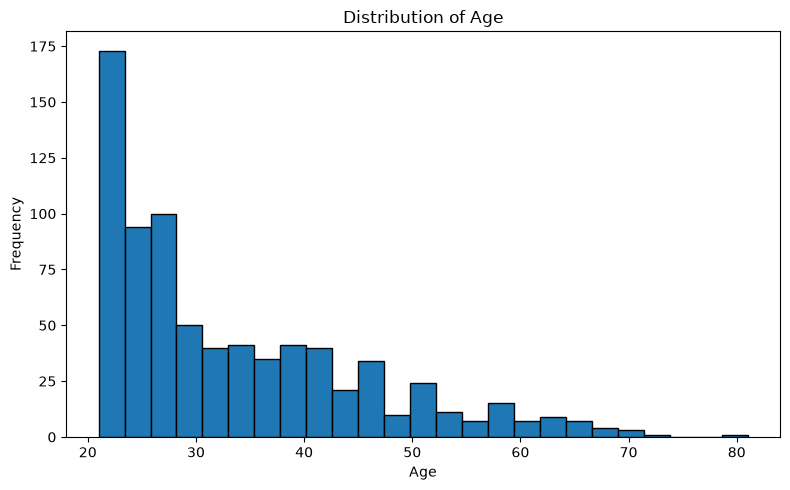

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=25, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The current `Age` range is from 21 to 81. `Age` has no zero values.

The distribution is concentrated more heavily in the younger adult range,
with the interquartile range from 24.0 to 41.0 and a median of 29.0.
Compared with `Glucose`, `BMI`, and `BloodPressure`, this feature does
not show the same zero-value issue. No outliers are removed.

### Chart 5: Blood Pressure Distribution

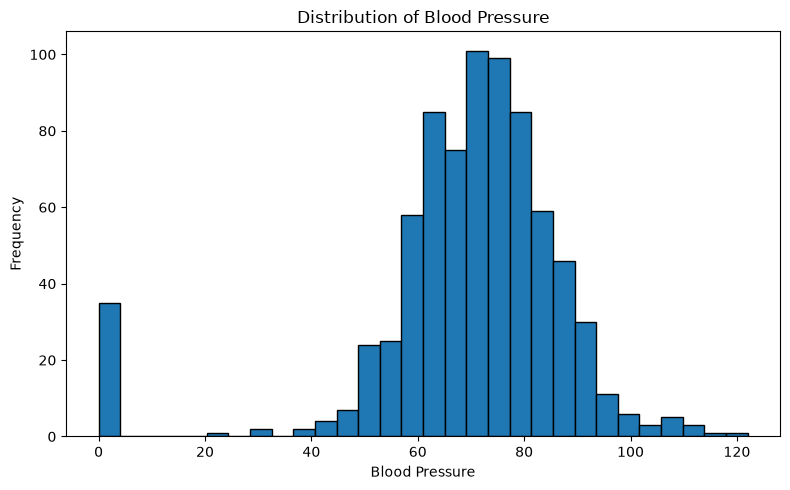

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["BloodPressure"], bins=30, edgecolor="black")
plt.title("Distribution of Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation

The current `BloodPressure` range is from 0 to 122. There are 35
observations where `BloodPressure = 0`; these values are recorded as
potential invalid values.

Most non-zero observations are concentrated around the middle of the
observed range, with the interquartile range from 62.0 to 80.0 and a
median of 72.0. The zero values are not processed in this EDA step.

## 10. EDA Summary

Based on the five distribution charts:

1. `Outcome` shows a moderate class imbalance: class `0` has 500 observations (65.10%), while class `1` has 268 observations (34.90%).
2. `Glucose` has 5 zero values that need to be reviewed later.
3. `BMI` has 11 zero values that need to be reviewed later.
4. `BloodPressure` has 35 zero values that need to be reviewed later.
5. `Age` has no zero values.
6. Raw-data visualization shows that Data Cleaning is necessary before building a model.
7. No data is modified during this EDA step.

No additional charts are created in this step. Feature importance and
Feature Selection are not discussed here because the final 6-feature
representation will be selected in a later step.

## 11. Data Cleaning Preparation

The raw dataset contains no directly encoded NaN values. However,
several health-related features contain zero values that were identified
during data inspection as potential invalid or missing observations.

For machine learning preparation, zero values in the following features
will be converted to NaN:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

`Pregnancies = 0` is retained because zero pregnancies is a valid value.

The original DataFrame `df` will not be modified. A separate feature
matrix will be created for machine learning.

Median imputation has not been performed at this step.

In [21]:
X = df.drop(columns=["Outcome"]).copy()
y = df["Outcome"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [22]:
X.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [23]:
X_raw = X.copy()

In [24]:
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

In [25]:
X.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [26]:
X.isnull().sum().sum()

np.int64(652)

In [27]:
(df[zero_as_missing] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

`df` remains unchanged and represents the original raw dataset. The
cleaned representation exists only in `X`.

Rows are not removed at this step. In particular, `Insulin` and
`SkinThickness` contain many potential missing values, so dropping rows
could remove too many observations. Missing values will be handled later
using imputation inside a Machine Learning Pipeline.

## 12. Train/Test Split

The dataset is split into training and testing subsets:

- 80% is used for training and model development.
- 20% is kept as a held-out test set.
- `random_state=42` makes the split reproducible.
- `stratify=y` helps preserve a similar class ratio in the training and test sets.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [30]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


In [31]:
y_train.value_counts().sort_index()

Outcome
0    400
1    214
Name: count, dtype: int64

In [32]:
y_train.value_counts(normalize=True).sort_index() * 100

Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

In [33]:
y_test.value_counts().sort_index()

Outcome
0    100
1     54
Name: count, dtype: int64

In [34]:
y_test.value_counts(normalize=True).sort_index() * 100

Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64

The train and test sets keep approximately the same `Outcome` class
ratio as the original dataset. This is the effect of using `stratify=y`.

No class balancing is performed. SMOTE, oversampling, and undersampling
are not used in this step.

In [35]:
X_train.isnull().sum()

Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [36]:
X_test.isnull().sum()

Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64

### Avoiding Data Leakage

The held-out test set must not influence model development.

Operations that learn information from data, such as:

- median imputation;
- standardization;
- feature selection;
- hyperparameter tuning;

will be learned using training data only.

The test set will be reserved for final evaluation after model selection
and experimentation are complete.

The deterministic conversion from known invalid zero values to NaN does
not learn statistical information from the test data. Median imputation
will be performed later through a Pipeline fit on the training data.

### Representation After Data Cleaning Preparation

```text
Raw CSV
→ 8 candidate numerical features
→ selected zero values converted to NaN
→ Train/Test Split
```

Current representation still contains 8 candidate features.

Missing values have not yet been imputed.

Feature selection has not yet been performed.

The final model will eventually use only 6 selected features.

## 13. Data Cleaning and Split Summary

- Original `df` remains unchanged.
- `X` initially contains 8 candidate features.
- Zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were represented as NaN in `X`.
- No observations were dropped.
- Dataset was divided into 80% training and 20% testing.
- Stratified splitting was used.
- Missing-value imputation has not yet been performed.
- Feature selection has not yet been performed.
- Test data will remain untouched during model development.

## 14. Feature Selection

The original representation contains eight candidate input features. The
final assignment requires the intelligent system to use six features.

Feature selection is therefore performed using training data only. The
held-out test set is not used to determine which features are selected.

A Random Forest feature-importance analysis is used as a feature ranking
method.

The Random Forest used in this section is only a feature-selection tool.
It is not counted as the final Random Forest model evaluation.

### Avoiding Feature-Selection Leakage

Feature selection is part of model development.

If `X_test` were used to choose the best features, information from the
held-out test set would influence the final model.

Therefore:

```text
X_train + y_train
→ feature selection

X_test
→ not used for feature selection
```

The test set remains reserved for final evaluation.

### Temporary Imputation for Feature Ranking

This temporary imputation is used only to allow the feature-ranking
algorithm to operate on `X_train`.

It does not modify `X_train` itself.

The final machine-learning preprocessing pipeline will perform its own
imputation later.

In [37]:
from sklearn.impute import SimpleImputer

In [38]:
feature_selection_imputer = SimpleImputer(
    strategy="median"
)

X_train_selector_array = feature_selection_imputer.fit_transform(
    X_train
)

X_train_selector = pd.DataFrame(
    X_train_selector_array,
    columns=X_train.columns,
    index=X_train.index
)

In [39]:
X_train_selector.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [40]:
X_train_selector.isnull().sum().sum()

np.int64(0)

In [41]:
X_train.isnull().sum()

Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

The selector version has no missing values after temporary median
imputation. The original `X_train` still contains NaN values and remains
unchanged.

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
feature_ranker = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

feature_ranker.fit(
    X_train_selector,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [44]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_ranker.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Rank"] = (
    feature_importance_df.index + 1
)

feature_importance_df = feature_importance_df[
    ["Rank", "Feature", "Importance"]
]

feature_importance_df.round(4)

,Rank,Feature,Importance
0,1,Glucose,0.2679
1,2,BMI,0.1598
2,3,DiabetesPedigreeFunction,0.1244
3,4,Age,0.1214
4,5,Insulin,0.0906
5,6,BloodPressure,0.0850
6,7,Pregnancies,0.0794
7,8,SkinThickness,0.0715


In [45]:
feature_importance_df["Importance"].sum()

np.float64(1.0)

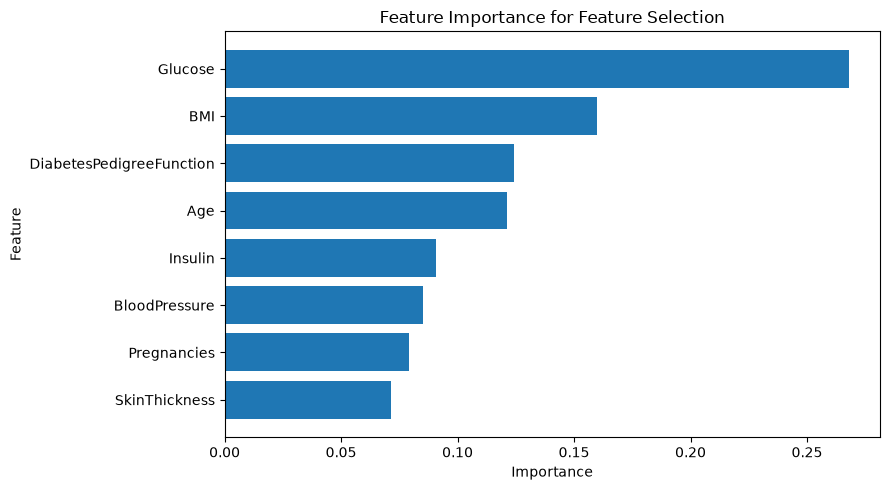

In [46]:
plt.figure(figsize=(9, 5))

importance_plot_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.barh(
    importance_plot_df["Feature"],
    importance_plot_df["Importance"]
)

plt.title("Feature Importance for Feature Selection")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [47]:
selected_features = (
    feature_importance_df
    .head(6)["Feature"]
    .tolist()
)

print("Selected 6 features:")
for feature in selected_features:
    print("-", feature)

Selected 6 features:
- Glucose
- BMI
- DiabetesPedigreeFunction
- Age
- Insulin
- BloodPressure


In [48]:
excluded_features = [
    feature
    for feature in X_train.columns
    if feature not in selected_features
]

print("Excluded features:")
for feature in excluded_features:
    print("-", feature)

Excluded features:
- Pregnancies
- SkinThickness


In [49]:
X_train_6 = X_train[selected_features].copy()
X_test_6 = X_test[selected_features].copy()

print("X_train_6:", X_train_6.shape)
print("X_test_6 :", X_test_6.shape)

X_train_6: (614, 6)
X_test_6 : (154, 6)


In [50]:
X_train_6.columns.tolist()

['Glucose',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Insulin',
 'BloodPressure']

In [51]:
X_test_6.columns.tolist()

['Glucose',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Insulin',
 'BloodPressure']

In [52]:
X_train_6.columns.equals(X_test_6.columns)

True

In [53]:
X_train_6.isnull().sum()

Glucose                       4
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
Insulin                     290
BloodPressure                23
dtype: int64

In [54]:
X_test_6.isnull().sum()

Glucose                      1
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
Insulin                     84
BloodPressure               12
dtype: int64

### Selected Six-Feature Representation

Based on the training-only feature ranking, the six selected features are:

1. `Glucose`
2. `BMI`
3. `DiabetesPedigreeFunction`
4. `Age`
5. `Insulin`
6. `BloodPressure`

The initial representation was:

```text
x ∈ R^8
```

After feature selection, the final input representation becomes:

```text
x_selected ∈ R^6
```

where the six dimensions correspond to the six selected features.

### Raw Feature vs Final Feature Set

```text
Raw CSV
→ 8 candidate numerical features
→ selected invalid zeros represented as NaN
→ Train/Test Split
→ Training-only feature ranking
→ 6 selected features
→ future preprocessing
→ future ML models
```

`X_train` and `X_test` still exist with 8 features.

`X_train_6` and `X_test_6` are the 6-feature representation for the
final system.

Official imputation has not yet been performed.

Scaling has not yet been performed.

The five main machine learning models have not yet been trained.

In [55]:
import json

selected_features_path = PROJECT_ROOT / "models" / "selected_features.json"

with selected_features_path.open("w", encoding="utf-8") as file:
    json.dump({"selected_features": selected_features}, file, indent=4)

print(selected_features_path)
print(selected_features_path.exists())

/home/hiubeo/Documents/TKHTTM/Assignment01_Diabetes/models/selected_features.json
True


## 15. Feature Selection Summary

- Feature-selection method: Random Forest feature importance.
- Feature selection used only the training data.
- Initial number of candidate features: 8.
- Final number of selected features: 6.
- Selected features: `Glucose`, `BMI`, `DiabetesPedigreeFunction`, `Age`, `Insulin`, `BloodPressure`.
- Excluded features: `Pregnancies`, `SkinThickness`.
- `X_train_6` shape: `(614, 6)`.
- `X_test_6` shape: `(154, 6)`.
- The test set was not used for feature ranking.
- Final imputation and scaling have not yet been performed.

This step does not claim that the 6-feature representation is always
better than the 8-feature representation. That will be checked later
through a controlled experiment.

## 16. Preprocessing Pipeline

The final six-feature representation still contains missing values, and
the selected numerical features have different numerical scales.

Preprocessing will include:

1. Median Imputation
2. Standardization

The intended pipeline is:

```text
6 Selected Features
→ Median Imputation
→ StandardScaler
→ Machine Learning Model
```

The imputer and scaler will be fit inside each training fold during
cross-validation. Preprocessing is not fit on the full dataset, and it is
not fit on `X_test_6`. An sklearn `Pipeline` is used to avoid data
leakage.

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [57]:
preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

### Median Imputation

Missing values are replaced using the median value learned from the
training portion of each cross-validation fold.

Median is used because it is less sensitive to extreme values than the
arithmetic mean.

No median is calculated on the full `X_train_6`, and missing values are
not filled manually.

### Feature Standardization

The six selected numerical features have different numerical ranges.

`StandardScaler` transforms each feature according to the mean and
standard deviation learned from training data.

This is particularly relevant for models such as:

- Logistic Regression
- KNN
- SVM

Tree-based models do not strongly depend on feature scale, but a
consistent preprocessing protocol will initially be used for model
comparison.

No manual transformation is applied to the data in this step.

### Why Use a Pipeline?

A Pipeline ensures that preprocessing is learned independently inside
each cross-validation fold.

For each fold:

```text
Training fold
→ learn median
→ learn scaler parameters
→ train classifier

Validation fold
→ apply learned median
→ apply learned scaler
→ prediction
```

This prevents validation information from leaking into preprocessing.

## 17. Baseline Model

Before evaluating learned machine-learning models, a simple baseline is
required.

The baseline uses:

```text
DummyClassifier(strategy="most_frequent")
```

It predicts the most frequent class and therefore does not learn a
meaningful relationship between the health-related input features and
the target.

The baseline acts as a reference point. A useful learned model should
provide meaningful improvement over this simple strategy.

In [58]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [59]:
baseline_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        DummyClassifier(
            strategy="most_frequent"
        )
    )
])

The baseline may never predict the positive class. To keep the metric
outputs explicit and avoid undefined precision warnings, the positive
class metrics use `zero_division=0`. This does not change the meaning of
the baseline; it records undefined positive-class precision, recall, and
F1-score as 0.

In [60]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

In [61]:
baseline_cv = cross_validate(
    baseline_pipeline,
    X_train_6,
    y_train,
    cv=5,
    scoring=scoring
)

In [62]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Mean": [
        baseline_cv["test_accuracy"].mean(),
        baseline_cv["test_precision"].mean(),
        baseline_cv["test_recall"].mean(),
        baseline_cv["test_f1"].mean()
    ],
    "Std": [
        baseline_cv["test_accuracy"].std(),
        baseline_cv["test_precision"].std(),
        baseline_cv["test_recall"].std(),
        baseline_cv["test_f1"].std()
    ]
})

baseline_results.round(4)

,Metric,Mean,Std
0,Accuracy,0.6515,0.0021
1,Precision,0.0000,0.0000
2,Recall,0.0000,0.0000
3,F1-score,0.0000,0.0000


In [63]:
baseline_accuracy = baseline_cv["test_accuracy"].mean()

print(f"Mean Baseline Accuracy: {baseline_accuracy:.4f}")

Mean Baseline Accuracy: 0.6515


In [64]:
X_train_6.isnull().sum()

Glucose                       4
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
Insulin                     290
BloodPressure                23
dtype: int64

### Baseline Interpretation

The most-frequent baseline predicts the majority class, which is class
`0` in the training data.

Because class `0` accounts for about 65% of the data, the baseline
accuracy is close to that proportion. The mean baseline accuracy is
0.6515 with a standard deviation of 0.0021 across 5 folds.

Precision, recall, and F1-score for the positive class are all 0.0000
because this baseline does not identify class `1`. This shows why looking
only at accuracy can be misleading. The learned models evaluated later
must be compared using multiple metrics.

## 18. Preprocessing and Baseline Summary

- Final model representation currently has 6 selected features.
- Missing values will be median-imputed.
- Numerical features will be standardized.
- Preprocessing is encapsulated inside an sklearn Pipeline.
- Baseline model: `DummyClassifier(strategy="most_frequent")`.
- Baseline evaluation uses 5-fold cross-validation on training data only.
- Baseline mean Accuracy: 0.6515.
- Baseline Accuracy standard deviation: 0.0021.
- Baseline mean Precision: 0.0000.
- Baseline mean Recall: 0.0000.
- Baseline mean F1-score: 0.0000.
- The baseline has not used the held-out test set.
- The five learned machine-learning models have not yet been trained.

## 19. Traditional Machine Learning Models

Five traditional machine learning algorithms are investigated using the
same six-feature representation and preprocessing protocol:

1. Logistic Regression
2. k-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Support Vector Machine

All five models receive the same numerical representation and are
evaluated under the same cross-validation protocol.

### 19.1 Logistic Regression

- Input: six-dimensional numerical feature vector after preprocessing.
- Learning idea: learns a linear combination of input features and converts it to class probability using the logistic/sigmoid function.
- Learned parameters: feature coefficients and intercept.
- Strengths: simple, efficient, interpretable, and useful as a baseline learned model.
- Weaknesses: assumes a relatively simple decision boundary and may not capture complex nonlinear relationships.

### 19.2 k-Nearest Neighbors

k-Nearest Neighbors predicts a new observation using nearby training
observations. Similarity is measured using distance, and the parameter
`k` controls the number of neighbors.

KNN is sensitive to feature scale, so `StandardScaler` is particularly
relevant. Its strengths are simplicity and the ability to model nonlinear
patterns. Its weaknesses are sensitivity to scaling and `k`, and slower
prediction when datasets become larger.

In this initial experiment, `k=5` is used. No tuning of `k` is performed.

### 19.3 Decision Tree

A Decision Tree recursively divides the feature space using feature
thresholds. It learns a tree of decision rules, and the splitting
criterion guides how the tree is constructed.

Decision Trees can model nonlinear relationships and are relatively easy
to interpret. However, they can overfit when the tree becomes too
complex.

No `max_depth` tuning is performed in this step.

### 19.4 Random Forest

Random Forest is an ensemble of multiple decision trees. The trees are
trained using different samples and feature subsets, and their
predictions are combined.

Compared with a single Decision Tree, Random Forest often generalizes
better and can capture nonlinear relationships. It is less directly
interpretable than a single tree.

In Experiment 1, a fixed initial configuration is used:

```text
n_estimators = 100
random_state = 42
```

No `max_depth` tuning is performed in this step.

### 19.5 Support Vector Machine

Support Vector Machine learns a separating decision boundary with a
margin. The RBF kernel allows nonlinear decision boundaries.

SVM is sensitive to feature scale, can perform well on structured
classification problems, and may be computationally more expensive and
less interpretable.

This experiment uses:

```text
kernel="rbf"
random_state=42
```

This initial experiment uses the RBF kernel without probability calibration because only scalar classification metrics are evaluated. No tuning of `C` or `gamma` is performed in this step.

## 20. Experiment 1 - Model Comparison

### Experimental Question

Which of the five traditional machine learning algorithms provides the
strongest classification performance when using the same six-feature
representation, preprocessing pipeline, and cross-validation protocol?

Controlled factors:

- `X_train_6` and `y_train`
- six selected features
- median imputation
- `StandardScaler`
- cross-validation folds
- evaluation metrics

Changed factor:

- classification algorithm

The held-out test set is not used in this experiment.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

In [66]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    )
}

In [67]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

The same `scoring` dictionary from the baseline step is reused. It
contains Accuracy, Precision, Recall, and F1-score. The positive-class
metrics use `zero_division=0` through the scorer definitions from the
baseline section.

In [68]:
model_cv_results = []

for name, model in models.items():

    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        model_pipeline,
        X_train_6,
        y_train,
        cv=cv_strategy,
        scoring=scoring
    )

    model_cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

experiment1_df = pd.DataFrame(model_cv_results)

experiment1_df.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,Logistic Regression,0.7866,0.0245,0.7434,0.0613,0.5980,0.0198,0.6620,0.0320
1,KNN,0.7279,0.0502,0.6308,0.0948,0.5651,0.0357,0.5938,0.0561
2,Decision Tree,0.6645,0.0380,0.5186,0.0501,0.5466,0.0606,0.5315,0.0519
3,Random Forest,0.7589,0.0268,0.6799,0.0593,0.5934,0.0252,0.6324,0.0319
4,SVM,0.7752,0.0235,0.7328,0.0804,0.5746,0.0288,0.6412,0.0253


In [69]:
experiment1_summary_df = experiment1_df[
    [
        "Model",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean"
    ]
].rename(columns={
    "Accuracy Mean": "Accuracy",
    "Precision Mean": "Precision",
    "Recall Mean": "Recall",
    "F1 Mean": "F1-score"
})

experiment1_summary_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7866,0.7434,0.5980,0.6620
1,KNN,0.7279,0.6308,0.5651,0.5938
2,Decision Tree,0.6645,0.5186,0.5466,0.5315
3,Random Forest,0.7589,0.6799,0.5934,0.6324
4,SVM,0.7752,0.7328,0.5746,0.6412


In [70]:
accuracy_improvement_df = experiment1_summary_df[
    ["Model", "Accuracy"]
].copy()

accuracy_improvement_df["Accuracy Improvement vs Baseline"] = (
    accuracy_improvement_df["Accuracy"] - baseline_accuracy
)

accuracy_improvement_df.round(4)

,Model,Accuracy,Accuracy Improvement vs Baseline
0,Logistic Regression,0.7866,0.1351
1,KNN,0.7279,0.0764
2,Decision Tree,0.6645,0.0130
3,Random Forest,0.7589,0.1075
4,SVM,0.7752,0.1238


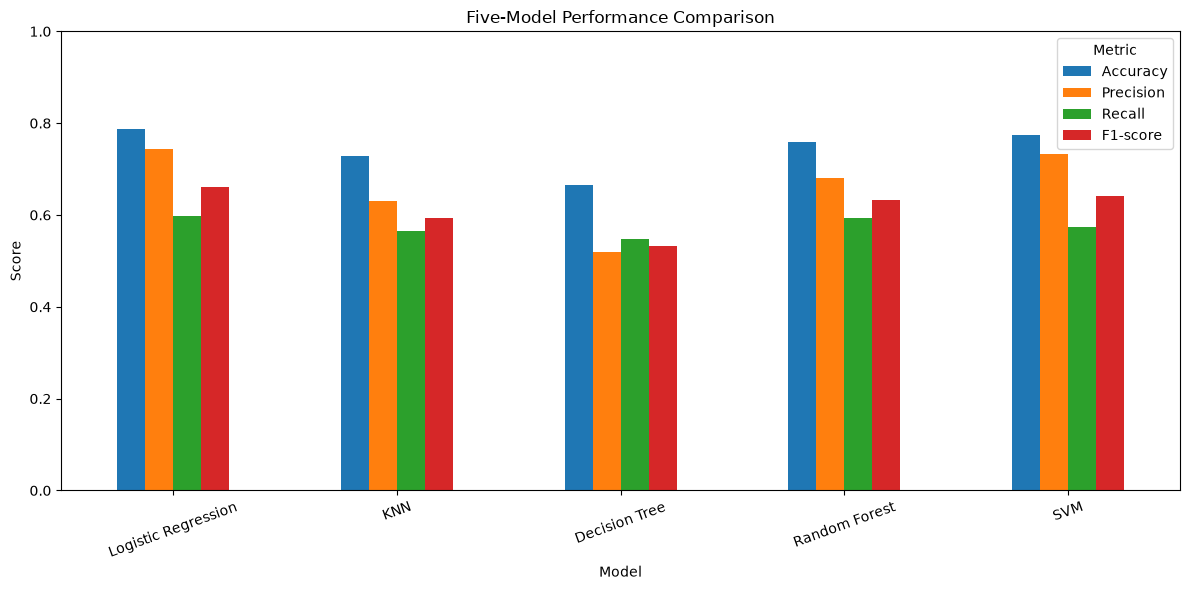

In [71]:
plot_df = experiment1_summary_df.set_index("Model")

plot_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Five-Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

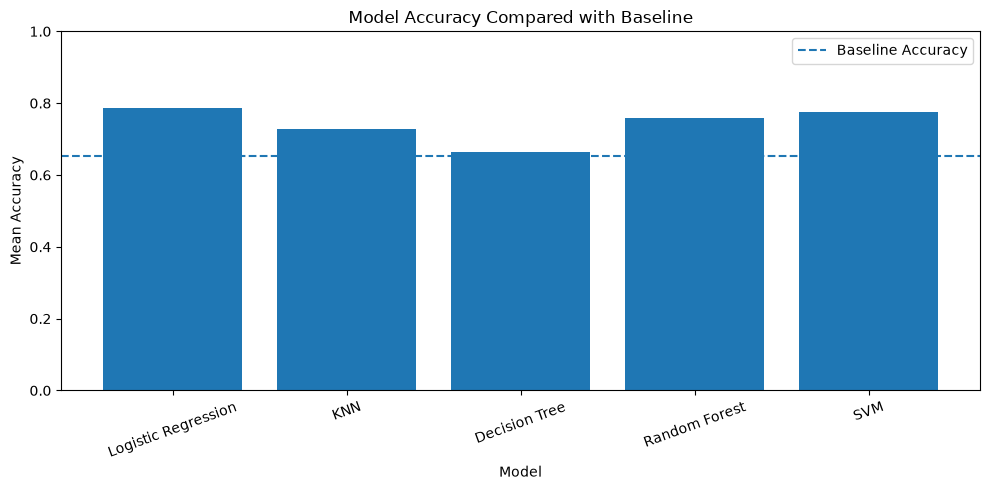

In [72]:
plt.figure(figsize=(10, 5))
plt.bar(
    experiment1_summary_df["Model"],
    experiment1_summary_df["Accuracy"]
)
plt.axhline(
    y=baseline_accuracy,
    linestyle="--",
    label="Baseline Accuracy"
)
plt.title("Model Accuracy Compared with Baseline")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
best_initial_model_by_f1 = experiment1_summary_df.loc[
    experiment1_summary_df["F1-score"].idxmax()
]

print("Best initial model candidate by F1-score:")
print("Model:", best_initial_model_by_f1["Model"])
print("Accuracy:", round(best_initial_model_by_f1["Accuracy"], 4))
print("Precision:", round(best_initial_model_by_f1["Precision"], 4))
print("Recall:", round(best_initial_model_by_f1["Recall"], 4))
print("F1-score:", round(best_initial_model_by_f1["F1-score"], 4))

Best initial model candidate by F1-score:
Model: Logistic Regression
Accuracy: 0.7866
Precision: 0.7434
Recall: 0.598
F1-score: 0.662


### Experiment 1 Analysis

Based on the 5-fold cross-validation results:

1. Logistic Regression has the highest Accuracy: 0.7866.
2. Logistic Regression has the highest Precision: 0.7434.
3. Logistic Regression has the highest Recall: 0.5980.
4. Logistic Regression has the highest F1-score: 0.6620.
5. All five learned models exceed the baseline Accuracy of 0.6515.
6. Decision Tree performs lower than Random Forest across Accuracy, Precision, Recall, and F1-score. This is consistent with the idea that an ensemble can reduce variance compared with a single tree, although this result should still be confirmed in later experiments.
7. There is some trade-off between Precision and Recall. For example, SVM has relatively high Precision but lower Recall than Logistic Regression, while Decision Tree has lower Precision but a Recall closer to KNN.

KNN and SVM may benefit from the standardized representation because
they are scale-sensitive. Tree-based models can capture nonlinear
relationships, while Random Forest combines multiple trees to improve
stability compared with a single Decision Tree. These are algorithmic
interpretations, not final causal conclusions.

No confusion matrix is produced in this step because the held-out test
set is still reserved for final evaluation.

## 21. Experiment 1 Summary

- Five traditional machine learning models were evaluated.
- Evaluation used 5-fold stratified cross-validation.
- Only training data was used.
- All models used the same six-feature representation.
- All models used the same preprocessing protocol.
- Baseline Accuracy: 0.6515.
- Best initial model candidate by F1-score: Logistic Regression.
- Logistic Regression F1-score: 0.6620.
- The held-out test set was not used.
- Hyperparameter tuning was not performed.
- No deployment model was saved in this step.

This is not the final model selection. Further experiments are still
needed before final evaluation.

## 22. Experiment 2 - Hyperparameter Investigation

### Experimental Question

How does the Logistic Regression regularization parameter `C` affect
classification performance?

`C` controls the inverse strength of regularization.

```text
Smaller C
→ stronger regularization

Larger C
→ weaker regularization
```

The experiment changes only `C` while keeping the feature representation,
preprocessing, dataset, cross-validation strategy, and evaluation metrics
unchanged.

### Controlled Experimental Design

Fixed:

- `X_train_6`
- `y_train`
- six selected features
- `SimpleImputer(strategy="median")`
- `StandardScaler`
- Logistic Regression algorithm
- `max_iter=2000`
- `random_state=42`
- 5-fold `StratifiedKFold`
- scoring metrics

Changed:

- `C` only

The held-out test set is not used.

In [74]:
c_values = [
    0.01,
    0.1,
    1,
    10,
    100
]

In [75]:
logistic_c_results = []

for c in c_values:

    model = LogisticRegression(
        C=c,
        max_iter=2000,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train_6,
        y_train,
        cv=cv_strategy,
        scoring=scoring
    )

    logistic_c_results.append({
        "C": c,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

experiment2_df = pd.DataFrame(logistic_c_results)

experiment2_df.round(4)

,C,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,0.01,0.7638,0.0118,0.7775,0.0574,0.4580,0.0325,0.5744,0.0214
1,0.10,0.7866,0.0222,0.7511,0.0564,0.5839,0.0209,0.6564,0.0309
2,1.00,0.7866,0.0245,0.7434,0.0613,0.5980,0.0198,0.6620,0.0320
3,10.00,0.7866,0.0245,0.7434,0.0613,0.5980,0.0198,0.6620,0.0320
4,100.00,0.7866,0.0245,0.7434,0.0613,0.5980,0.0198,0.6620,0.0320


In [76]:
experiment2_summary_df = experiment2_df[
    [
        "C",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean"
    ]
].rename(columns={
    "Accuracy Mean": "Accuracy",
    "Precision Mean": "Precision",
    "Recall Mean": "Recall",
    "F1 Mean": "F1-score"
})

experiment2_summary_df.round(4)

,C,Accuracy,Precision,Recall,F1-score
0,0.01,0.7638,0.7775,0.4580,0.5744
1,0.10,0.7866,0.7511,0.5839,0.6564
2,1.00,0.7866,0.7434,0.5980,0.6620
3,10.00,0.7866,0.7434,0.5980,0.6620
4,100.00,0.7866,0.7434,0.5980,0.6620


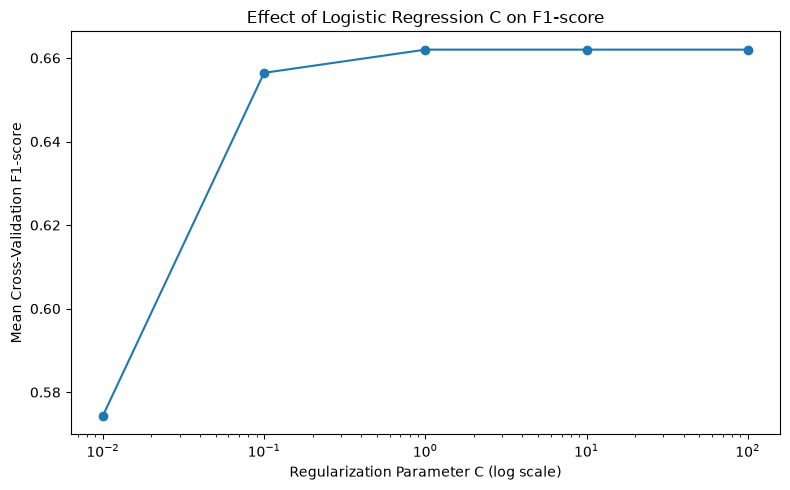

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(
    experiment2_summary_df["C"],
    experiment2_summary_df["F1-score"],
    marker="o"
)
plt.xscale("log")
plt.title("Effect of Logistic Regression C on F1-score")
plt.xlabel("Regularization Parameter C (log scale)")
plt.ylabel("Mean Cross-Validation F1-score")
plt.tight_layout()
plt.show()

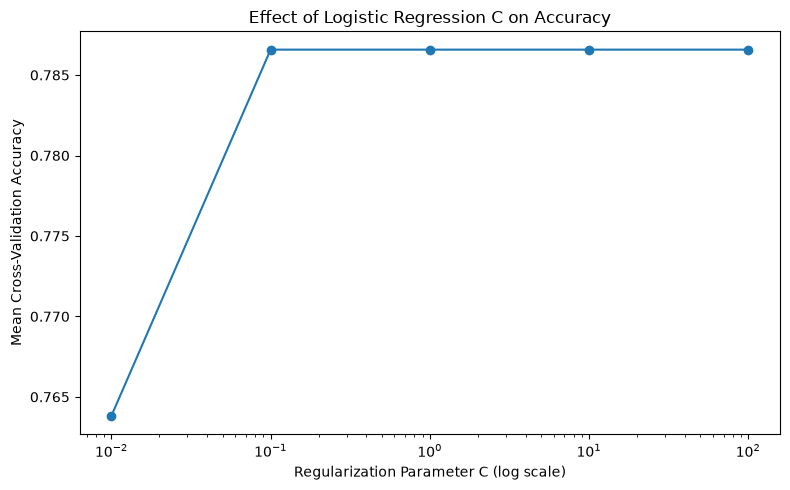

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(
    experiment2_summary_df["C"],
    experiment2_summary_df["Accuracy"],
    marker="o"
)
plt.xscale("log")
plt.title("Effect of Logistic Regression C on Accuracy")
plt.xlabel("Regularization Parameter C (log scale)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.tight_layout()
plt.show()

In [79]:
best_c_result = experiment2_df.loc[
    experiment2_df["F1 Mean"].idxmax()
]

print("Best C by F1:", best_c_result["C"])
print("Accuracy:", round(best_c_result["Accuracy Mean"], 4))
print("Precision:", round(best_c_result["Precision Mean"], 4))
print("Recall:", round(best_c_result["Recall Mean"], 4))
print("F1-score:", round(best_c_result["F1 Mean"], 4))

Best C by F1: 1.0
Accuracy: 0.7866
Precision: 0.7434
Recall: 0.598
F1-score: 0.662


In [80]:
initial_c_result = experiment2_df.loc[
    experiment2_df["C"] == 1
].iloc[0]

f1_improvement_vs_default_c = (
    best_c_result["F1 Mean"] - initial_c_result["F1 Mean"]
)

accuracy_improvement_vs_default_c = (
    best_c_result["Accuracy Mean"] - initial_c_result["Accuracy Mean"]
)

print("Initial C:", initial_c_result["C"])
print("Best C:", best_c_result["C"])
print("F1 improvement:", round(f1_improvement_vs_default_c, 4))
print("Accuracy improvement:", round(accuracy_improvement_vs_default_c, 4))

Initial C: 1.0
Best C: 1.0
F1 improvement: 0.0
Accuracy improvement: 0.0


### Experiment 2 Analysis

Based on the 5-fold cross-validation results:

- Accuracy is highest for `C = 0.1`, `C = 1`, `C = 10`, and `C = 100`, all with mean Accuracy of 0.7866. Using `idxmax()`, the first highest value is `C = 0.1`.
- Precision is highest for `C = 0.01`, with mean Precision of 0.7775.
- Recall is highest for `C = 1`, `C = 10`, and `C = 100`, all with mean Recall of 0.5980. Using `idxmax()`, the first highest value is `C = 1`.
- F1-score is highest for `C = 1`, `C = 10`, and `C = 100`, all with mean F1-score of 0.6620. Using `idxmax()`, the selected best `C` by F1-score is `C = 1`.

Very strong regularization (`C = 0.01`) produces lower Recall and lower
F1-score, even though Precision is higher. This indicates a trade-off:
the model is more conservative about predicting the positive class.

From `C = 1` onward, the metrics are stable in this experiment. The best
configuration selected by F1-score does not improve over the default
`C = 1`; both F1 improvement and Accuracy improvement are 0.0000.

This result does not prove that larger or smaller `C` values are always
better. It only describes this controlled experiment on the current
training data and selected feature representation.

## 23. Experiment 2 Summary

- Model investigated: Logistic Regression.
- Hyperparameter investigated: `C`.
- Tested `C` values: `0.01`, `0.1`, `1`, `10`, `100`.
- Best `C` according to mean CV F1-score: `1`.
- Best configuration metrics: Accuracy 0.7866, Precision 0.7434, Recall 0.5980, F1-score 0.6620.
- F1 improvement compared with default `C = 1`: 0.0000.
- Accuracy improvement compared with default `C = 1`: 0.0000.
- Only training data was used.
- The held-out test set remains untouched.
- No model was saved in this step.

## 24. Experiment 3 - Representation Investigation

### Experimental Question

How does reducing the input representation from eight candidate features
to six selected features affect Logistic Regression classification
performance?

Two representations are compared:

1. All 8 candidate features.
2. The 6 features selected using training-data feature importance.

The machine-learning algorithm, preprocessing protocol,
cross-validation strategy, and metrics remain unchanged.

### Controlled Experimental Design

Fixed:

- Logistic Regression
- `C = 1`
- `max_iter = 2000`
- `random_state = 42`
- `SimpleImputer(strategy="median")`
- `StandardScaler`
- 5-fold `StratifiedKFold`
- same CV split strategy
- same target `y_train`
- same scoring metrics

Changed:

- input representation only

Representation A: 8 candidate features

Representation B: 6 selected features

Held-out test data is not used.

### Representation A - All Eight Features

Input:

```text
x_all ∈ R^8
```

Features:

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

Dataset used: `X_train`

Missing values remain in `X_train` and must be handled by the
preprocessing Pipeline.

### Representation B - Six Selected Features

Input:

```text
x_selected ∈ R^6
```

Features are taken from the existing `selected_features` variable.

Dataset used: `X_train_6`

The six-feature representation was produced using feature ranking based
only on training data.

In [81]:
selected_features

['Glucose',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Insulin',
 'BloodPressure']

In [82]:
representation_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

In [83]:
pipeline_8_features = Pipeline([
    (
        "preprocessor",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            random_state=42
        )
    )
])

In [84]:
pipeline_6_features = Pipeline([
    (
        "preprocessor",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            random_state=42
        )
    )
])

In [85]:
scores_8 = cross_validate(
    pipeline_8_features,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring
)

In [86]:
scores_6 = cross_validate(
    pipeline_6_features,
    X_train_6,
    y_train,
    cv=cv_strategy,
    scoring=scoring
)

In [87]:
experiment3_results = [
    {
        "Representation": "8 Features",
        "Feature Count": 8,
        "Accuracy Mean": scores_8["test_accuracy"].mean(),
        "Accuracy Std": scores_8["test_accuracy"].std(),
        "Precision Mean": scores_8["test_precision"].mean(),
        "Precision Std": scores_8["test_precision"].std(),
        "Recall Mean": scores_8["test_recall"].mean(),
        "Recall Std": scores_8["test_recall"].std(),
        "F1 Mean": scores_8["test_f1"].mean(),
        "F1 Std": scores_8["test_f1"].std()
    },
    {
        "Representation": "6 Selected Features",
        "Feature Count": 6,
        "Accuracy Mean": scores_6["test_accuracy"].mean(),
        "Accuracy Std": scores_6["test_accuracy"].std(),
        "Precision Mean": scores_6["test_precision"].mean(),
        "Precision Std": scores_6["test_precision"].std(),
        "Recall Mean": scores_6["test_recall"].mean(),
        "Recall Std": scores_6["test_recall"].std(),
        "F1 Mean": scores_6["test_f1"].mean(),
        "F1 Std": scores_6["test_f1"].std()
    }
]

experiment3_df = pd.DataFrame(experiment3_results)

experiment3_df.round(4)

,Representation,Feature Count,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,8 Features,8,0.7882,0.0191,0.7638,0.0598,0.5748,0.0227,0.6545,0.0244
1,6 Selected Features,6,0.7866,0.0245,0.7434,0.0613,0.5980,0.0198,0.6620,0.0320


In [88]:
experiment3_summary_df = experiment3_df[
    [
        "Representation",
        "Feature Count",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean"
    ]
].rename(columns={
    "Accuracy Mean": "Accuracy",
    "Precision Mean": "Precision",
    "Recall Mean": "Recall",
    "F1 Mean": "F1-score"
})

experiment3_summary_df.round(4)

,Representation,Feature Count,Accuracy,Precision,Recall,F1-score
0,8 Features,8,0.7882,0.7638,0.5748,0.6545
1,6 Selected Features,6,0.7866,0.7434,0.5980,0.6620


In [89]:
representation_difference_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "8 Features": [
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "8 Features",
            "Accuracy"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "8 Features",
            "Precision"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "8 Features",
            "Recall"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "8 Features",
            "F1-score"
        ].iloc[0]
    ],
    "6 Features": [
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "6 Selected Features",
            "Accuracy"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "6 Selected Features",
            "Precision"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "6 Selected Features",
            "Recall"
        ].iloc[0],
        experiment3_summary_df.loc[
            experiment3_summary_df["Representation"] == "6 Selected Features",
            "F1-score"
        ].iloc[0]
    ]
})

representation_difference_df["Difference (6 - 8)"] = (
    representation_difference_df["6 Features"]
    - representation_difference_df["8 Features"]
)

representation_difference_df.round(4)

,Metric,8 Features,6 Features,Difference (6 - 8)
0,Accuracy,0.7882,0.7866,-0.0017
1,Precision,0.7638,0.7434,-0.0204
2,Recall,0.5748,0.5980,0.0233
3,F1-score,0.6545,0.6620,0.0074


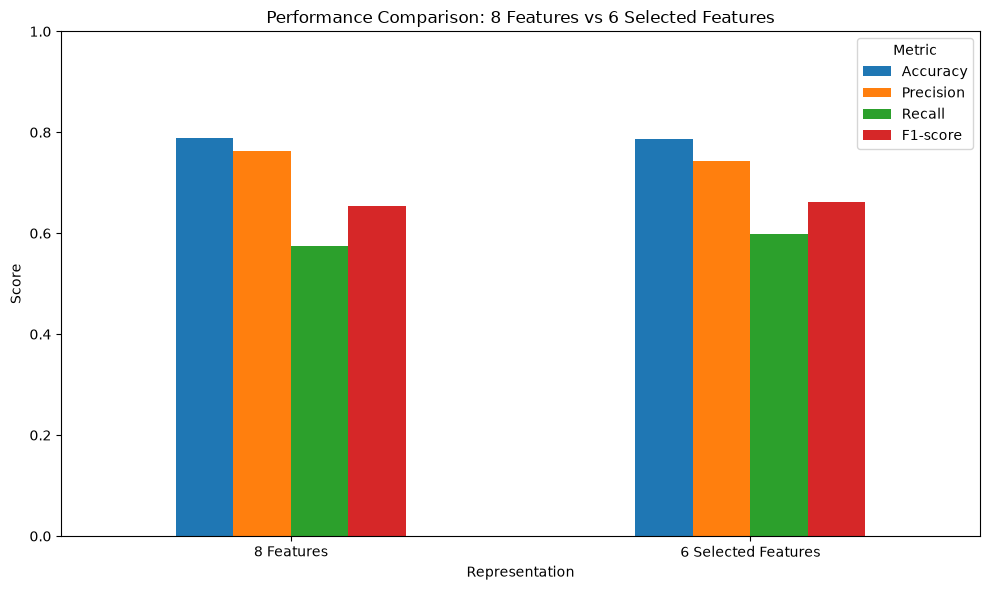

In [90]:
representation_plot_df = experiment3_summary_df.set_index("Representation")

representation_plot_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: 8 Features vs 6 Selected Features")
plt.xlabel("Representation")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

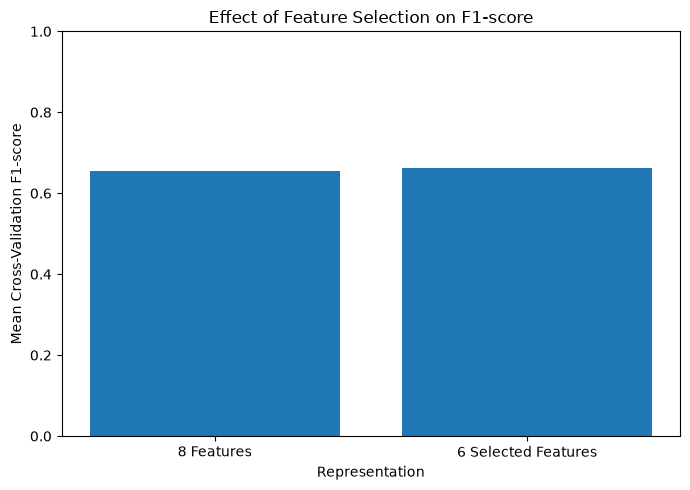

In [91]:
plt.figure(figsize=(7, 5))
plt.bar(
    experiment3_summary_df["Representation"],
    experiment3_summary_df["F1-score"]
)
plt.title("Effect of Feature Selection on F1-score")
plt.xlabel("Representation")
plt.ylabel("Mean Cross-Validation F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [92]:
best_representation_by_f1 = experiment3_summary_df.loc[
    experiment3_summary_df["F1-score"].idxmax()
]

print("Best representation by F1-score:")
print("Representation:", best_representation_by_f1["Representation"])
print("Feature Count:", int(best_representation_by_f1["Feature Count"]))
print("Accuracy:", round(best_representation_by_f1["Accuracy"], 4))
print("Precision:", round(best_representation_by_f1["Precision"], 4))
print("Recall:", round(best_representation_by_f1["Recall"], 4))
print("F1-score:", round(best_representation_by_f1["F1-score"], 4))

Best representation by F1-score:
Representation: 6 Selected Features
Feature Count: 6
Accuracy: 0.7866
Precision: 0.7434
Recall: 0.598
F1-score: 0.662


### Experiment 3 Analysis

Based on the 5-fold cross-validation results:

1. The 8-feature representation has Accuracy 0.7882.
2. The 6-feature representation has Accuracy 0.7866.
3. F1-score changes by +0.0074 when moving from 8 features to 6 selected features.
4. Precision changes by -0.0204.
5. Recall changes by +0.0233.
6. Removing `Pregnancies` and `SkinThickness` makes performance nearly unchanged overall, with a small decrease in Accuracy and Precision but a small increase in Recall and F1-score.
7. Reducing from 8 to 6 features is acceptable in this experiment because the reduced representation provides comparable performance while using fewer input dimensions.

The six-feature representation is particularly relevant to the final
application because the Streamlit interface will require only six user
inputs instead of eight. However, usability must not be used as the sole
justification for feature selection; predictive performance must also be
considered.

### Methodology Note

The six features were selected earlier using the training data only. The
held-out test data played no role in feature selection.

The selected feature set is treated as a fixed representation in this
controlled experiment.

This is not a fully nested feature-selection cross-validation procedure.

## 25. Experiment 3 Summary

- Algorithm fixed: Logistic Regression.
- `C` fixed: `1`.
- Preprocessing fixed: median imputation and standardization.
- Changed variable: representation, comparing 8 features vs 6 selected features.
- 8-feature metrics: Accuracy 0.7882, Precision 0.7638, Recall 0.5748, F1-score 0.6545.
- 6-feature metrics: Accuracy 0.7866, Precision 0.7434, Recall 0.5980, F1-score 0.6620.
- Difference in F1-score: +0.0074 for the 6-feature representation.
- Representation selected by F1-score: 6 selected features.
- Held-out test set remains unused.
- No deployment model was saved in this step.

## 26. Controlled Experiments Summary

| Experiment | Question | Changed Variable | Fixed Variables | Main Result |
| --- | --- | --- | --- | --- |
| Experiment 1 | Which ML algorithm performs best? | Algorithm | Six selected features, preprocessing, 5-fold Stratified CV, scoring metrics, training data | Logistic Regression achieved the best initial F1-score: 0.6620. |
| Experiment 2 | How does Logistic Regression `C` affect performance? | `C` | Logistic Regression, six selected features, preprocessing, 5-fold Stratified CV, scoring metrics, training data | Best `C` by F1-score was `1`; it did not improve over default `C = 1`. |
| Experiment 3 | How does feature representation affect performance? | 8 vs 6 features | Logistic Regression with `C = 1`, preprocessing, 5-fold Stratified CV, scoring metrics, training data | 6 selected features achieved slightly higher F1-score than 8 features: 0.6620 vs 0.6545. |

Based on cross-validation experiments, Logistic Regression with `C = 1`
and the 6 selected features is a candidate final configuration. This is
not yet a held-out test evaluation.

## 27. Final Model Selection

The final configuration is decided entirely from the training data and
cross-validation experiments before viewing the held-out test set.

Final configuration:

- Model: Logistic Regression
- Hyperparameter: `C = 1.0`
- Representation: six selected numerical features
- Features:
  - `Glucose`
  - `BMI`
  - `DiabetesPedigreeFunction`
  - `Age`
  - `Insulin`
  - `BloodPressure`
- Preprocessing:
  - Median Imputation
  - `StandardScaler`

Reasons for this selection:

1. Logistic Regression achieved the highest F1-score in Experiment 1.
2. Experiment 2 showed that `C = 1` achieved the best F1-score; larger `C` values did not improve performance.
3. Experiment 3 showed that the six-feature representation had slightly higher F1-score than the eight-feature representation while requiring fewer inputs.
4. This selection was made before using the held-out test set.

In [93]:
final_model = Pipeline([
    (
        "preprocessor",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            max_iter=2000,
            random_state=42
        )
    )
])

In [94]:
final_model.fit(
    X_train_6,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Glucose','BMI','DiabetesPedigreeFunction','Age','Insulin', 'BloodPressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected 

In [95]:
final_test_pred = final_model.predict(
    X_test_6
)

final_test_probability = final_model.predict_proba(
    X_test_6
)[:, 1]

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [97]:
final_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_precision = precision_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_pred,
    zero_division=0
)

print("Final Held-out Test Evaluation")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

Final Held-out Test Evaluation
Accuracy : 0.7208
Precision: 0.6222
Recall   : 0.5185
F1-score : 0.5657


In [98]:
final_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_metrics_df.round(4)

,Metric,Score
0,Accuracy,0.7208
1,Precision,0.6222
2,Recall,0.5185
3,F1-score,0.5657


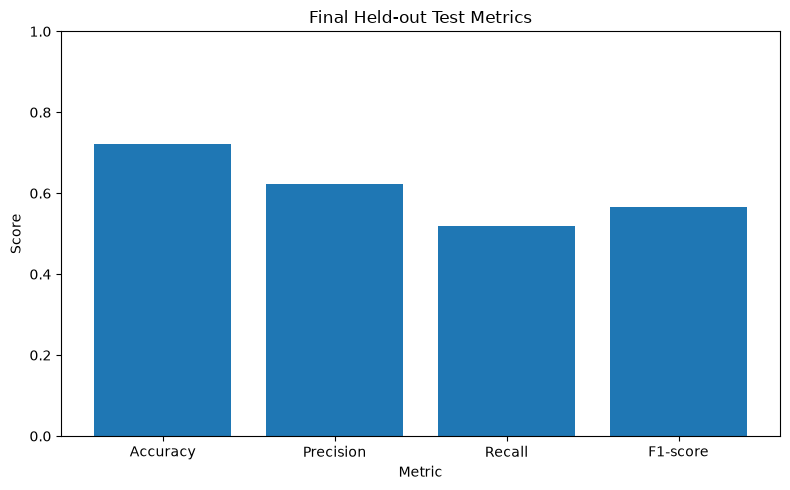

In [99]:
plt.figure(figsize=(8, 5))
plt.bar(
    final_metrics_df["Metric"],
    final_metrics_df["Score"]
)
plt.title("Final Held-out Test Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [100]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

final_cm

array([[83, 17],
       [26, 28]])

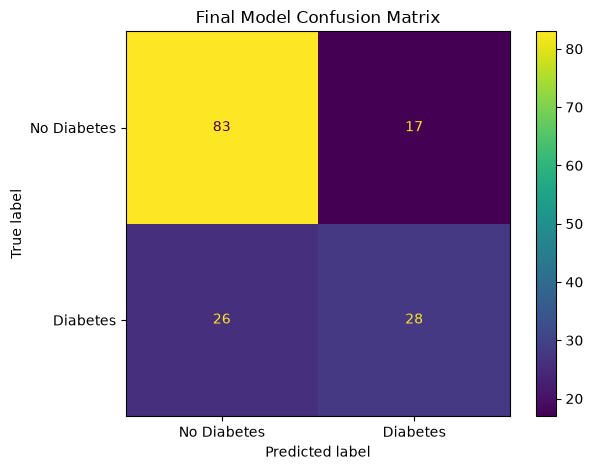

In [101]:
ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
).plot()

plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

In [102]:
TN, FP, FN, TP = final_cm.ravel()

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)

True Negative : 83
False Positive: 17
False Negative: 26
True Positive : 28


### Confusion Matrix Interpretation

True Negative means the actual class is `0` and the model predicts class
`0`.

False Positive means the actual class is `0` but the model predicts class
`1`.

False Negative means the actual class is `1` but the model predicts class
`0`.

True Positive means the actual class is `1` and the model predicts class
`1`.

The final confusion matrix contains 83 True Negatives, 17 False
Positives, 26 False Negatives, and 28 True Positives. The model correctly
identifies more negative-class observations than positive-class
observations. The 26 False Negatives reduce positive-class Recall.

In [103]:
print(classification_report(
    y_test,
    final_test_pred,
    target_names=[
        "No Diabetes",
        "Diabetes"
    ],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

 No Diabetes     0.7615    0.8300    0.7943       100
    Diabetes     0.6222    0.5185    0.5657        54

    accuracy                         0.7208       154
   macro avg     0.6918    0.6743    0.6800       154
weighted avg     0.7126    0.7208    0.7141       154



The classification report shows precision, recall, and F1-score for each
class. Macro average treats both classes equally, while weighted average
accounts for the number of observations in each class.

In [104]:
cv_vs_test_df = pd.DataFrame({
    "Evaluation": [
        "Cross-Validation Candidate",
        "Held-out Test"
    ],
    "Accuracy": [
        0.7866,
        final_accuracy
    ],
    "Precision": [
        0.7434,
        final_precision
    ],
    "Recall": [
        0.5980,
        final_recall
    ],
    "F1-score": [
        0.6620,
        final_f1
    ]
})

cv_vs_test_df.round(4)

,Evaluation,Accuracy,Precision,Recall,F1-score
0,Cross-Validation Candidate,0.7866,0.7434,0.5980,0.6620
1,Held-out Test,0.7208,0.6222,0.5185,0.5657


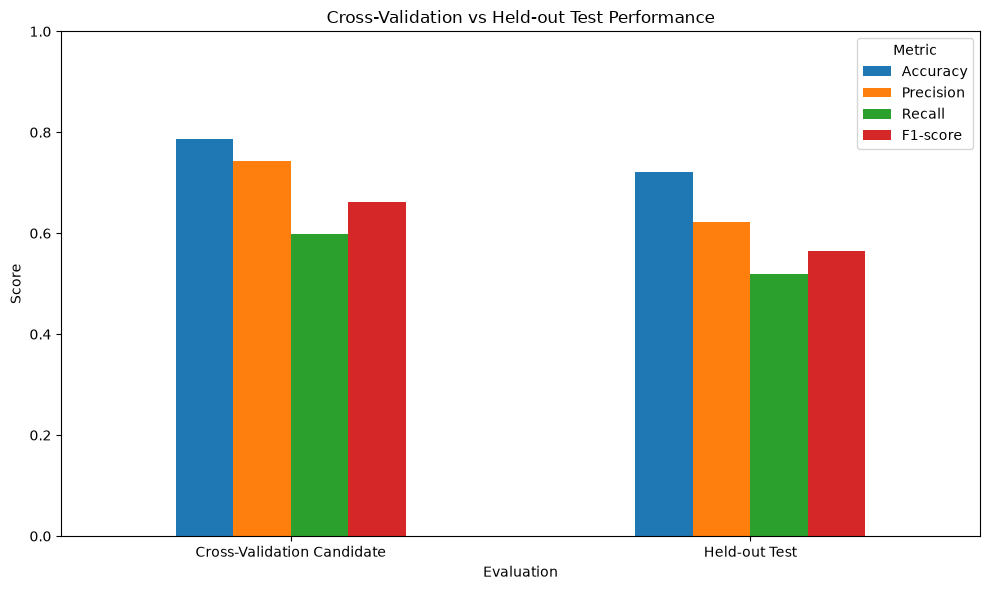

In [105]:
cv_vs_test_plot_df = cv_vs_test_df.set_index("Evaluation")

cv_vs_test_plot_df[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cross-Validation vs Held-out Test Performance")
plt.xlabel("Evaluation")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [106]:
cv_vs_test_difference_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "CV Candidate": [0.7866, 0.7434, 0.5980, 0.6620],
    "Held-out Test": [final_accuracy, final_precision, final_recall, final_f1]
})

cv_vs_test_difference_df["Difference (Test - CV)"] = (
    cv_vs_test_difference_df["Held-out Test"]
    - cv_vs_test_difference_df["CV Candidate"]
)

cv_vs_test_difference_df.round(4)

,Metric,CV Candidate,Held-out Test,Difference (Test - CV)
0,Accuracy,0.7866,0.7208,-0.0658
1,Precision,0.7434,0.6222,-0.1212
2,Recall,0.5980,0.5185,-0.0795
3,F1-score,0.6620,0.5657,-0.0963


### Final Evaluation Analysis

Based on the held-out test set:

1. Held-out Accuracy is 0.7208.
2. Held-out Precision is 0.6222.
3. Held-out Recall is 0.5185.
4. Held-out F1-score is 0.5657.
5. The final model exceeds the baseline Accuracy of 0.6515 by 0.0693.
6. Test scores are lower than cross-validation estimates. The differences are -0.0658 for Accuracy, -0.1212 for Precision, -0.0795 for Recall, and -0.0963 for F1-score.
7. The confusion matrix shows 17 False Positives and 26 False Negatives, so the model makes more False Negative errors than False Positive errors.
8. Positive-class Recall is limited: the model correctly identifies 28 out of 54 positive-class observations.
9. The final model demonstrates useful predictive performance on this held-out dataset, while still producing classification errors.

The result is above the baseline, but the gap between cross-validation and
held-out test performance should be reported transparently.

### Post-Test Methodology Note

The held-out test set was used only after model, hyperparameter, and
representation choices had been fixed.

No additional tuning or feature selection is performed after seeing the
test results.

This preserves the test set as an independent estimate of final
generalization performance.

The model is not saved in this step. Model persistence and deployment
artifacts will be handled later.

## 28. Final Evaluation Summary

- Selected final algorithm: Logistic Regression.
- Selected `C`: `1.0`.
- Selected features: `Glucose`, `BMI`, `DiabetesPedigreeFunction`, `Age`, `Insulin`, `BloodPressure`.
- Preprocessing: median imputation followed by standardization.
- Held-out test size: 154 observations.
- Final Accuracy: 0.7208.
- Final Precision: 0.6222.
- Final Recall: 0.5185.
- Final F1-score: 0.5657.
- Confusion Matrix values: TN = 83, FP = 17, FN = 26, TP = 28.
- Baseline Accuracy: 0.6515; final Accuracy improvement over baseline: 0.0693.
- Compared with the CV candidate estimate, held-out test performance is lower across all four scalar metrics.
- No post-test tuning was performed.
- No model was saved in this step.

## 29. Deployment Model Preparation

The scientific final model remains Logistic Regression with `C = 1`.

However, the final web application is required to allow users to choose
among five traditional machine learning models. Therefore, five
deployment pipelines are trained using the same six-feature
representation and the same training data.

These deployment models are provided for interactive comparison on the
web application. They are not used to reopen the scientific
model-selection process.

In [ ]:
import json
import joblib

In [ ]:
def create_preprocessor():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

In [ ]:
deployment_models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    )
}

In [ ]:
deployment_pipelines = {}

for name, model in deployment_models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            create_preprocessor()
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train_6,
        y_train
    )

    deployment_pipelines[name] = pipeline

The deployment pipelines are fit using `X_train_6` and `y_train` only.
No deployment model is evaluated on the held-out test set in this step.

In [ ]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

model_file_map = {
    "Logistic Regression": "logistic_regression.joblib",
    "KNN": "knn.joblib",
    "Decision Tree": "decision_tree.joblib",
    "Random Forest": "random_forest.joblib",
    "SVM": "svm.joblib"
}

for name, pipeline in deployment_pipelines.items():
    model_path = models_dir / model_file_map[name]
    joblib.dump(pipeline, model_path)

In [ ]:
joblib_files = sorted(models_dir.glob("*.joblib"))

for path in joblib_files:
    print(path.name, path.stat().st_size)

In [ ]:
selected_features_path = models_dir / "selected_features.json"

with selected_features_path.open(encoding="utf-8") as file:
    selected_features_payload = json.load(file)

expected_selected_features = [
    "Glucose",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Insulin",
    "BloodPressure"
]

if selected_features_payload["selected_features"] != expected_selected_features:
    raise ValueError("selected_features.json does not match the expected feature order.")

selected_features_payload

In [ ]:
cv_metrics = {
    "Logistic Regression": {
        "accuracy_cv": 0.7866,
        "precision_cv": 0.7434,
        "recall_cv": 0.5980,
        "f1_cv": 0.6620
    },
    "KNN": {
        "accuracy_cv": 0.7279,
        "precision_cv": 0.6308,
        "recall_cv": 0.5651,
        "f1_cv": 0.5938
    },
    "Decision Tree": {
        "accuracy_cv": 0.6645,
        "precision_cv": 0.5186,
        "recall_cv": 0.5466,
        "f1_cv": 0.5315
    },
    "Random Forest": {
        "accuracy_cv": 0.7589,
        "precision_cv": 0.6799,
        "recall_cv": 0.5934,
        "f1_cv": 0.6324
    },
    "SVM": {
        "accuracy_cv": 0.7752,
        "precision_cv": 0.7328,
        "recall_cv": 0.5746,
        "f1_cv": 0.6412
    }
}

In [ ]:
model_registry = {
    "final_selected_model": "Logistic Regression",
    "selected_features": selected_features,
    "models": {},
    "final_test_metrics": {
        "model": "Logistic Regression",
        "accuracy": 0.7208,
        "precision": 0.6222,
        "recall": 0.5185,
        "f1": 0.5657
    }
}

for name in deployment_models:
    model_registry["models"][name] = {
        "file": model_file_map[name],
        **cv_metrics[name],
        "scientific_final_model": name == "Logistic Regression",
        "supports_probability": hasattr(deployment_pipelines[name], "predict_proba")
    }

model_registry_path = models_dir / "model_registry.json"

with model_registry_path.open("w", encoding="utf-8") as file:
    json.dump(model_registry, file, indent=4)

print(model_registry_path)
print(model_registry_path.exists())

In [ ]:
loaded_deployment_models = {}

for name, filename in model_file_map.items():
    loaded_deployment_models[name] = joblib.load(models_dir / filename)

print("Loaded successfully:")
for name in loaded_deployment_models:
    print("-", name)

In [ ]:
sample_columns = pd.DataFrame(
    columns=selected_features
)

sample_columns.columns.tolist()

In [ ]:
probability_support_df = pd.DataFrame({
    "Model": list(deployment_pipelines.keys()),
    "Supports Probability": [
        hasattr(pipeline, "predict_proba")
        for pipeline in deployment_pipelines.values()
    ]
})

probability_support_df

### Probability Output Note

Most deployment models support `predict_proba()`.

The deployed SVM configuration does not expose probability estimates in
the current implementation.

For SVM, the application will display the predicted class and may display
a decision score instead of calling it a probability.

An SVM decision-function score must not be labeled as a probability.

## 30. Deployment Model Summary

- The scientific final model remains Logistic Regression with `C = 1`.
- Five pipelines were trained for interactive web comparison.
- All five pipelines use the same six selected features.
- All five pipelines use median imputation and `StandardScaler`.
- All five pipelines were fit using training data only.
- No new held-out test comparison was performed.
- Five `.joblib` files were created in `models/`.
- `model_registry.json` was created.
- `selected_features.json` is reused and its feature order was verified.
- `app.py` was not modified in this step.
- `neo4j_service.py` was not modified in this step.

## 32. Knowledge Graph Design

Neo4j is used to represent relationships between the machine learning
models, selected input features, observations, predictions, and
classification outcomes.

The Knowledge Graph schema is:

```text
Model
  └── USES_FEATURE → Feature

Observation
  ├── HAS_MEASUREMENT → Feature
  └── HAS_PREDICTION → Prediction
                           ├── PRODUCED_BY → Model
                           └── PREDICTED_AS → Outcome
```

Static graph components:

- 5 `Model` nodes for the deployment models.
- 6 `Feature` nodes from `models/selected_features.json`.
- 2 `Outcome` nodes: `0` for No Diabetes and `1` for Diabetes.
- 30 `USES_FEATURE` relationships because all 5 deployment models use the same 6 selected features.

Prediction observations are represented anonymously. Each future
prediction can create an `Observation` node connected to feature
measurements and a `Prediction` node.

### Knowledge Graph Purpose

Machine learning and the Knowledge Graph serve different roles.

Machine Learning:

- learns predictive patterns;
- produces class predictions.

Neo4j Knowledge Graph:

- represents model-feature relationships;
- stores structured prediction relationships;
- supports graph queries and prediction-history exploration.

Neo4j does not replace the machine-learning model. It provides a graph
representation layer around the model artifacts and prediction records.

### Privacy Note

Prediction observations are anonymous.

The current implementation does not store:

- name
- email
- account ID
- phone number

Only the six numerical input measurements, selected model, and model
output are represented.

### Extended Knowledge Representation

The Knowledge Graph contains both machine-learning system knowledge and
problem-domain structure.

Static knowledge includes:

- `Model`
- `Feature`
- `Representation`
- `Condition`
- `Outcome`
- `Metric`

Dynamic knowledge includes:

- `Observation`
- `Prediction`

The extended static graph makes the diabetes prediction system easier to
inspect in Neo4j Browser. It shows which models use which features, which
representation targets the Diabetes condition, and which metrics describe
model performance.

### Extended Graph Schema

```text
Model
 ├── USES_FEATURE ───────────────> Feature
 │                                  │
 │                                  ├── INPUT_FOR ──> Condition
 │                                  │
 │                                  └── PART_OF_REPRESENTATION
 │                                             │
 │                                             ▼
 ├── USES_REPRESENTATION ───────> Representation
 │                                             │
 │                                             └── TARGETS ──> Condition
 │
 ├── HAS_CV_METRIC ─────────────> Metric
 ├── HAS_FINAL_TEST_METRIC ─────> Metric
 └── SCIENTIFIC_FINAL_MODEL_FOR -> Condition

Outcome
 └── OUTCOME_OF ────────────────> Condition

Observation
 ├── HAS_MEASUREMENT ───────────> Feature
 └── HAS_PREDICTION ────────────> Prediction
                                      │
                                      ├── PRODUCED_BY ──> Model
                                      └── PREDICTED_AS ──> Outcome
```

`Feature -[:INPUT_FOR]-> Condition` means that the feature is an input
variable used by this intelligent system for predicting the Diabetes
classification target. It does not mean that the feature causes,
medically proves, or diagnoses Diabetes.

### Knowledge Graph vs Conventional Tables

A conventional table primarily stores rows and columns.

The Neo4j representation emphasizes relationships between system
entities. For example, the graph can directly traverse:

```text
Model → Feature → Condition
Model → Metric
Observation → Prediction → Model → Feature → Condition
```

This makes relationship-oriented exploration explicit.

A pharmacy-oriented Knowledge Graph might represent relationships such as
`Drug → Ingredient → Manufacturer → Condition`. This project applies the
same graph-oriented idea to the diabetes intelligent system using
`Model`, `Feature`, `Representation`, `Condition`, `Outcome`, `Metric`,
`Observation`, and `Prediction` entities.

No drug, medicine, manufacturer, or Long Chau data is added to the
current database.

## 33. Streamlit and Knowledge Graph Integration

The Streamlit application integrates the trained machine-learning
pipelines with Neo4j AuraDB.

For each successful prediction:

1. the selected saved model produces a prediction;
2. the result is displayed to the user;
3. an anonymous `Observation` is created;
4. six measurements connect the `Observation` to `Feature` nodes;
5. a `Prediction` node connects to the selected `Model` and `Outcome`;
6. these relationships become part of the Knowledge Graph.

Neo4j is treated as an optional supporting service. If Neo4j is
temporarily unavailable, the machine-learning prediction can still be
shown to the user.

### Application Architecture

```text
User
 |
 v
Streamlit
 |
 +----> Saved ML Pipeline
 |          |
 |          v
 |       Prediction
 |          |
 |          +----> Web Output
 |
 +----> Neo4j AuraDB
            |
            v
      Knowledge Graph
```

The Streamlit app does not train models. It loads saved `.joblib`
pipelines, performs prediction, and then attempts to save an anonymous
record to Neo4j.

### Integration Privacy Note

The graph does not store names, emails, phone numbers, or account
identifiers.

Prediction records are anonymous. They contain only the six numerical
input measurements, the selected model, model output, and timestamp.